Determine if reliance behaviors affect academic outcomes. Removing percentage of cautious use to prevent dummy variable trap.

In [1]:
import duckdb
import statsmodels.formula.api as smf
from pathlib import Path

query = """
    WITH student_reliance AS (
        SELECT 
            userId,
            COUNT(*) AS total_interactions,
            SUM(CASE WHEN reliance_category = 'THOUGHTLESS_USE' THEN 1 ELSE 0 END) AS thoughtless_count,
            SUM(CASE WHEN reliance_category = 'REFLECTIVE_USE' THEN 1 ELSE 0 END) AS reflective_count,
            SUM(CASE WHEN reliance_category = 'CAUTIOUS_USE' THEN 1 ELSE 0 END) AS cautious_count
        FROM read_parquet($dataset_path)
        GROUP BY userId
    ), grades_concatenated AS (
        SELECT *, 'f24' AS semester FROM read_csv($fall_sem)
        UNION ALL
        SELECT *, 's25' AS semester FROM read_csv($spring_sem)
    )
    SELECT 
        r.userId,
        r.total_interactions,
        (r.thoughtless_count * 100.0 / r.total_interactions) AS thoughtless_pct,
        (r.reflective_count * 100.0 / r.total_interactions) AS reflective_pct,
        (r.cautious_count * 100.0 / r.total_interactions) AS cautious_pct,
        g.llm AS assignment_avg,
        g.no_llm AS exam_avg,
        g.semester
    FROM student_reliance AS r
    JOIN grades_concatenated AS g 
      ON r.userId = g.userId
"""

with duckdb.connect() as connection:
    df_regression = connection.execute(
        query,
        {
            "dataset_path": str(
                Path("../data/outputs/clean_analytical_dataset.parquet")
            ),
            "fall_sem": str(
                Path("/workspaces/StudyChat/scores/f24_grades_released_normalized.csv")
            ),
            "spring_sem": str(
                Path("/workspaces/StudyChat/scores/s25_grades_released_normalized.csv")
            ),
        },
    ).df()

model = smf.ols(
    "exam_avg ~ thoughtless_pct + reflective_pct + total_interactions + C(semester)",
    data=df_regression,
)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:               exam_avg   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     1.497
Date:                Fri, 10 Jul 2026   Prob (F-statistic):              0.205
Time:                        15:23:00   Log-Likelihood:                 173.63
No. Observations:                 175   AIC:                            -337.3
Df Residuals:                     170   BIC:                            -321.4
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.8504      0

Variance inflation factor testing to determine collinearity of reliance percentages. Used since the condition number is affected by the difference in variable scales.

In [2]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

variables = ["thoughtless_pct", "reflective_pct", "total_interactions"]
X = df_regression[variables].dropna()

X = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF_Score"] = [
    variance_inflation_factor(X.values, i) for i in range(X.shape[1])
]

print(vif_data)

             Variable  VIF_Score
0               const  57.801242
1     thoughtless_pct   2.641874
2      reflective_pct   2.576705
3  total_interactions   1.053670


Conduct an F-test against a baseline model(average exam grade with predictors of total interactions and semester categorical variable) to check if the reliance categories improves explanatory power.

In [ ]:
from statsmodels.stats.anova import anova_lm

model_base = smf.ols(
    "exam_avg ~ total_interactions + C(semester)", data=df_regression
).fit()

model_full = smf.ols(
    "exam_avg ~ thoughtless_pct + reflective_pct + total_interactions + C(semester)",
    data=df_regression,
).fit()

print(anova_lm(model_base, model_full))

   df_resid       ssr  df_diff   ss_diff         F    Pr(>F)
0     172.0  1.410099      0.0       NaN       NaN       NaN
1     170.0  1.408566      2.0  0.001533  0.092509  0.911687


Run another model where the dependent variable is the average of assignment grades, where the use of the LLM is allowed

In [3]:
model_assignment = smf.ols(
    "assignment_avg ~ thoughtless_pct + reflective_pct + total_interactions + C(semester)",
    data=df_regression,
)
print(model_assignment.fit().summary())

                            OLS Regression Results                            
Dep. Variable:         assignment_avg   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     1.519
Date:                Fri, 10 Jul 2026   Prob (F-statistic):              0.199
Time:                        15:23:08   Log-Likelihood:                 244.08
No. Observations:                 175   AIC:                            -478.2
Df Residuals:                     170   BIC:                            -462.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.9556      0

Run regression model on assignment average - exam average as dependent variable

In [4]:
df_regression["grade_drop"] = (
    df_regression["assignment_avg"] - df_regression["exam_avg"]
)

model_delta = smf.ols(
    "grade_drop ~ thoughtless_pct + reflective_pct + total_interactions + C(semester)",
    data=df_regression,
)
print(model_delta.fit().summary())

                            OLS Regression Results                            
Dep. Variable:             grade_drop   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                 -0.014
Method:                 Least Squares   F-statistic:                    0.3837
Date:                Fri, 10 Jul 2026   Prob (F-statistic):              0.820
Time:                        15:23:25   Log-Likelihood:                 215.08
No. Observations:                 175   AIC:                            -420.2
Df Residuals:                     170   BIC:                            -404.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.1052      0

Perform another series of regressions where the initial message is removed. Initial messages are overwhelmingly labelled as thoughtless (56%), removing them reduces the percentage of thoughtless labels to 37%.

In [6]:
query_initial = """
    WITH student_reliance AS (
        SELECT 
            userId,
            COUNT(*) AS total_interactions,
            SUM(CASE WHEN reliance_category = 'THOUGHTLESS_USE' THEN 1 ELSE 0 END) AS thoughtless_count,
            SUM(CASE WHEN reliance_category = 'REFLECTIVE_USE' THEN 1 ELSE 0 END) AS reflective_count,
            SUM(CASE WHEN reliance_category = 'CAUTIOUS_USE' THEN 1 ELSE 0 END) AS cautious_count
        FROM read_parquet($dataset_path)
        WHERE interactionCount != 0
        GROUP BY userId
    ), grades_concatenated AS (
        SELECT *, 'f24' AS semester FROM read_csv($fall_sem)
        UNION ALL
        SELECT *, 's25' AS semester FROM read_csv($spring_sem)
    )
    SELECT 
        r.userId,
        r.total_interactions,
        (r.thoughtless_count * 100.0 / r.total_interactions) AS thoughtless_pct,
        (r.reflective_count * 100.0 / r.total_interactions) AS reflective_pct,
        (r.cautious_count * 100.0 / r.total_interactions) AS cautious_pct,
        g.llm AS assignment_avg,
        g.no_llm AS exam_avg,
        g.semester
    FROM student_reliance AS r
    JOIN grades_concatenated AS g 
      ON r.userId = g.userId
"""

with duckdb.connect() as connection:
    df_regression_initial = connection.execute(
        query_initial,
        {
            "dataset_path": str(
                Path("../data/outputs/clean_analytical_dataset.parquet")
            ),
            "fall_sem": str(
                Path("/workspaces/StudyChat/scores/f24_grades_released_normalized.csv")
            ),
            "spring_sem": str(
                Path("/workspaces/StudyChat/scores/s25_grades_released_normalized.csv")
            ),
        },
    ).df()

model_initial = smf.ols(
    "exam_avg ~ thoughtless_pct + reflective_pct + total_interactions + C(semester)",
    data=df_regression_initial,
)

print(model_initial.fit().summary())

                            OLS Regression Results                            
Dep. Variable:               exam_avg   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     1.506
Date:                Fri, 10 Jul 2026   Prob (F-statistic):              0.203
Time:                        15:25:02   Log-Likelihood:                 171.24
No. Observations:                 173   AIC:                            -332.5
Df Residuals:                     168   BIC:                            -316.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.8707      0

Assignment grades regression with no initial messages.

In [8]:
model_assignment_initial = smf.ols(
    "assignment_avg ~ thoughtless_pct + reflective_pct + total_interactions + C(semester)",
    data=df_regression_initial,
)
print(model_assignment_initial.fit().summary())

                            OLS Regression Results                            
Dep. Variable:         assignment_avg   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     1.429
Date:                Fri, 10 Jul 2026   Prob (F-statistic):              0.227
Time:                        16:21:18   Log-Likelihood:                 240.23
No. Observations:                 173   AIC:                            -470.5
Df Residuals:                     168   BIC:                            -454.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.9613      0

Regression on drop in grades from assignment average to exam average.

In [9]:
df_regression_initial["grade_drop"] = (
    df_regression_initial["assignment_avg"] - df_regression_initial["exam_avg"]
)

model_delta_initial = smf.ols(
    "grade_drop ~ thoughtless_pct + reflective_pct + total_interactions + C(semester)",
    data=df_regression_initial,
)
print(model_delta_initial.fit().summary())

                            OLS Regression Results                            
Dep. Variable:             grade_drop   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                 -0.015
Method:                 Least Squares   F-statistic:                    0.3757
Date:                Fri, 10 Jul 2026   Prob (F-statistic):              0.826
Time:                        16:23:27   Log-Likelihood:                 212.13
No. Observations:                 173   AIC:                            -414.3
Df Residuals:                     168   BIC:                            -398.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.0907      0

Perform elbow method and silhouette score to identify optimal clustering number for K-means clustering.

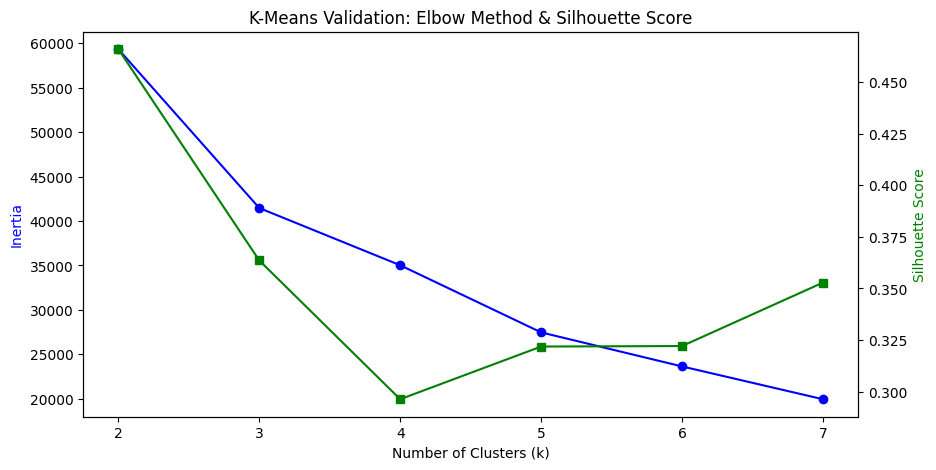

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

features = df_regression[["thoughtless_pct", "reflective_pct", "cautious_pct"]].dropna()

inertia = []
silhouette_scores = []
K_range = range(2, 8)  # Test 2 through 7 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(features)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(features, labels))

# Plotting the Elbow and Silhouette
fig, ax1 = plt.subplots(figsize=(10, 5))

# Elbow (Inertia)
ax1.plot(K_range, inertia, marker="o", color="blue", label="Inertia (Elbow)")
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia", color="blue")

# Silhouette
ax2 = ax1.twinx()
ax2.plot(
    K_range, silhouette_scores, marker="s", color="green", label="Silhouette Score"
)
ax2.set_ylabel("Silhouette Score", color="green")

plt.title("K-Means Validation: Elbow Method & Silhouette Score")
plt.show()

Perform K-means clustering informed by previous elbow method and silhouette scores

                  thoughtless_pct  reflective_pct  cautious_pct
behavior_profile                                               
0                       28.415732       40.911588     30.672679
1                       81.300908       11.751613      6.947479
2                       48.464630       31.230593     20.304777


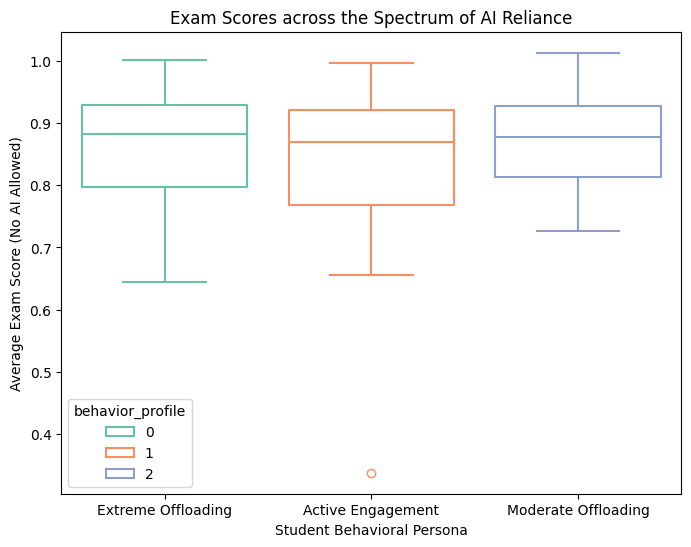

In [ ]:
import seaborn as sns

kmeans = KMeans(n_clusters=3, random_state=42)
df_regression["behavior_profile"] = kmeans.fit_predict(features)

cluster_profiles = df_regression.groupby("behavior_profile")[
    ["thoughtless_pct", "reflective_pct", "cautious_pct"]
].mean()

print(cluster_profiles)

# These need to be remapped based on how the unsupervised learning orders the clusters
# "Balanced" is the group with 28% thoughtless, 40% reflective, and 30% cautious
# "Moderate" is the group with 48% thoughtless, 31% reflective, and 20% cautious
# "Offloaders" is the group with 81% thoughtless
# Approximate values above are rounded down, some variance might occur due to unsupervised learning
cluster_names = {
    0: "Extreme Offloading",
    1: "Active Engagement",
    2: "Moderate Offloading",
}

df_regression["behavior_profile_name"] = df_regression["behavior_profile"].map(
    cluster_names
)

order = ["Extreme Offloading", "Active Engagement", "Moderate Offloading"]

plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_regression,
    x="behavior_profile_name",
    y="exam_avg",
    order=order,
    hue="behavior_profile",
    fill=False,
    palette="Set2",
)
plt.title("Exam Scores across the Spectrum of AI Reliance")
plt.xlabel("Student Behavioral Persona")
plt.ylabel("Average Exam Score (No AI Allowed)")
plt.show()

Checking emergence of reliance indicators across conversation length.

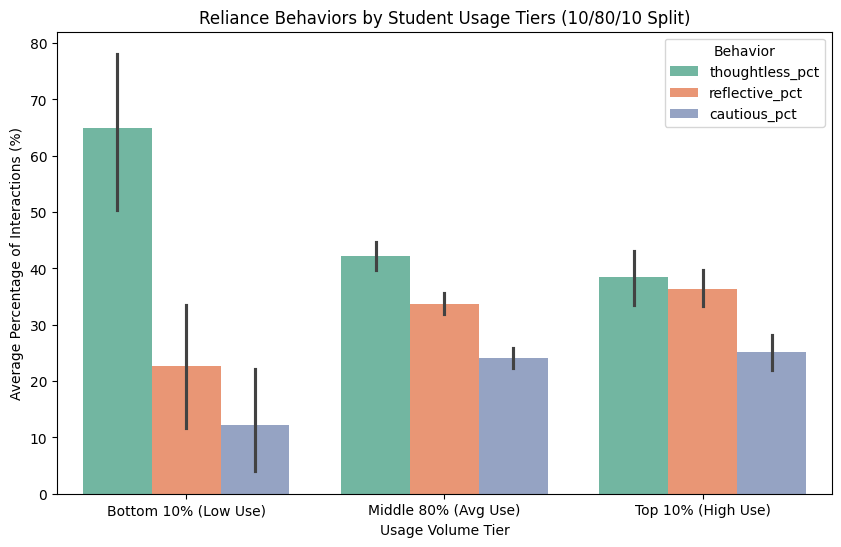

In [ ]:
# 1. Create the 10/80/10 Bins based on total_interactions
# The bins are: 0 to 10th percentile, 10th to 90th percentile, 90th to 100th
df_regression["usage_tier"] = pd.qcut(
    df_regression["total_interactions"],
    q=[0, 0.10, 0.90, 1.0],
    labels=["Bottom 10% (Low Use)", "Middle 80% (Avg Use)", "Top 10% (High Use)"],
)

# 2. Reshape the data so we can plot the three behaviors side-by-side
df_melted = df_regression.melt(
    id_vars=["usage_tier"],
    value_vars=["thoughtless_pct", "reflective_pct", "cautious_pct"],
    var_name="Reliance Type",
    value_name="Percentage",
)

# 3. Plot the Grouped Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_melted,
    x="usage_tier",
    y="Percentage",
    hue="Reliance Type",
    errorbar="ci",
    palette="Set2",
)
plt.title("Reliance Behaviors by Student Usage Tiers (10/80/10 Split)")
plt.ylabel("Average Percentage of Interactions (%)")
plt.xlabel("Usage Volume Tier")
plt.legend(title="Behavior")
plt.show()

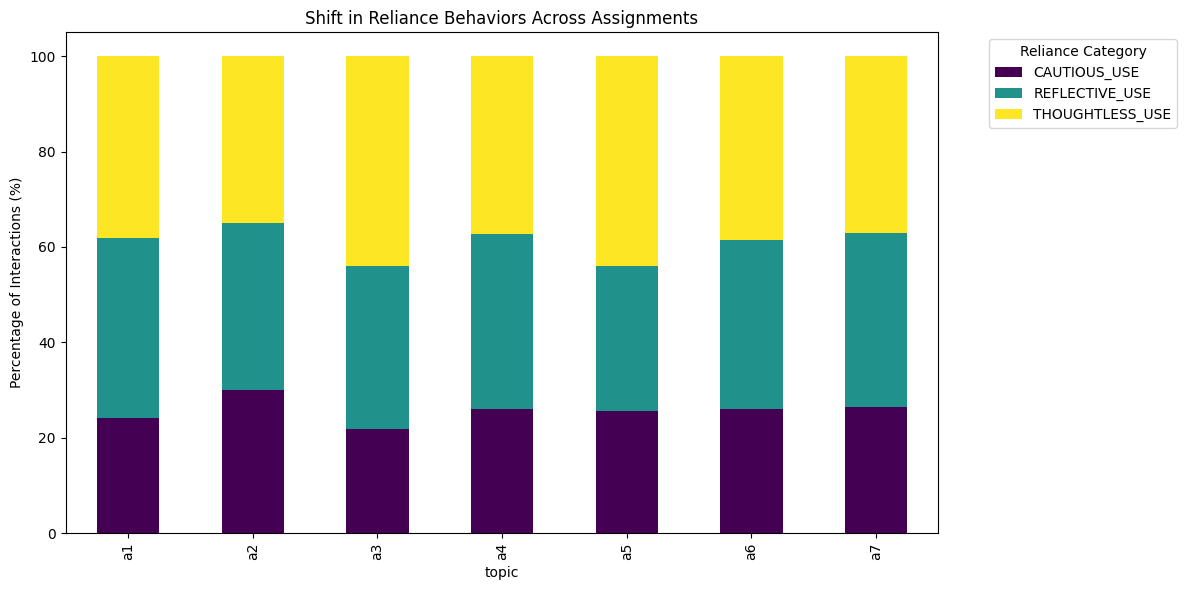

In [ ]:
query_topics = """
    SELECT 
        topic,
        reliance_category,
        COUNT(*) as cat_count
    FROM read_parquet($dataset_path)
    WHERE reliance_category IS NOT NULL
    GROUP BY topic, reliance_category
"""

with duckdb.connect() as connection:
    df_topics = connection.execute(
        query_topics,
        {"dataset_path": str(Path("../data/outputs/clean_analytical_dataset.parquet"))},
    ).df()

df_pivot = df_topics.pivot(
    index="topic", columns="reliance_category", values="cat_count"
).fillna(0)
df_pct = df_pivot.div(df_pivot.sum(axis=1), axis=0) * 100

df_pct.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="viridis")
plt.title("Shift in Reliance Behaviors Across Assignments")
plt.ylabel("Percentage of Interactions (%)")
plt.legend(title="Reliance Category", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()